# Tarea 2: Caminos aleatorios y difusión

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Problema 1: difusión fotónica en el Sol

Por `randomwalks1.ipynb`, sabemos que para un camino aleatorio la RMS del desplazamiento cumple
$$
L \sqrt{N}
$$
(La variación del desplazamiento respecto al promedio para pasos de tamaño $L$ en una dimensión). Entonces, para una distancia radial $R$:
$$
R^2 = L^2 N
\quad \Rightarrow \quad
N = \left(\frac{R}{L}\right)^2.
$$

Como cada paso toma un tiempo $\tau = L/c$, el tiempo total es
$$
t = N\tau = \frac{R^2}{Lc}.
$$

In [2]:
c = 3e8
R = 5e8
L = 5e-5

N = (R/L)**2
tau = L/c
years = N*tau / (365*24*60*60)

print(f"Numero de pasos N = {N:.2e}")
print(f"Tiempo por paso tau = {tau:.2e} s")
print(f"Tiempo total = {years:.2e} años")

Numero de pasos N = 1.00e+26
Tiempo por paso tau = 1.67e-13 s
Tiempo total = 5.28e+05 años


Es decir, el fotón necesita un número de pasos de orden $10^{26}$ y tarda un tiempo de orden $10^6 \text{ años}$.

## Problema 2: difusión térmica

### (a) Derivación de la ecuación de difusión térmica

Se nos da el flujo térmico
$$
\mathbf{J} = -K \nabla T
$$
y la conservación local de energía
$$
\frac{\partial E}{\partial t} = -\nabla \cdot \mathbf{J}.
$$
Si además
$$
E = c_p \rho T,
$$
con $c_p$ y $\rho$ constantes, entonces al derivar respecto al tiempo obtenemos
$$
\frac{\partial E}{\partial t}
=
\frac{\partial}{\partial t}(c_p\rho T)
=
c_p\rho\frac{\partial T}{\partial t}.
$$
Por otro lado, sustituyendo la ley de Fourier en la ecuación de conservación:
$$
\frac{\partial E}{\partial t}
=
-\nabla\cdot\mathbf{J}
=
-\nabla\cdot(-K\nabla T).
$$
Como $K$ es constante, puede sacarse de la divergencia:
$$
-\nabla\cdot(-K\nabla T)
=
K\,\nabla\cdot(\nabla T)
=
K\nabla^2T.
$$
Igualando ambas expresiones para $\partial E/\partial t$:
$$
c_p\rho\frac{\partial T}{\partial t}=K\nabla^2T.
$$
Ahora dividimos ambos lados entre $c_p\rho$:
$$
\boxed{
\frac{\partial T}{\partial t}
=
\frac{K}{c_p\rho}\nabla^2T
}.
$$
Si definimos la difusividad térmica
$$
\alpha\equiv\frac{K}{c_p\rho},
$$
queda la forma usual
$$
\boxed{\frac{\partial T}{\partial t}=\alpha\nabla^2T.}
$$

<!-- randomwalks2.ipynb#Corrientes y fuerzas externas -->
<!-- randomwalks2.ipynb#Derivación usando procesos estocásticos -->


### (b) Solución por análisis de Fourier para $T(x,0)=\sin(k_0 x)$

Partimos de
$$
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}.
$$

Ahora aplicamos la transformada de Fourier
$$
\widetilde{T}(k,t)=\int_{-\infty}^{\infty}T(x,t)e^{-ikx}\,dx.
$$
Sabemos que
$$
\mathcal{F}\left\{\frac{\partial^2T}{\partial x^2}\right\} = (ik)^2\widetilde T(k,t)=-k^2\widetilde T(k,t),
$$
y que
$$
\mathcal{F}\left\{\frac{\partial T}{\partial t}\right\} = \int_{-\infty}^{\infty} \frac{\partial T}{\partial t} e^{-ikx}dx = \frac{\partial}{\partial t} \int_{-\infty}^{\infty} T(x,t)e^{-ikx}dx = \frac{\partial \widetilde{T}}{\partial t}
$$
entonces, obtenemos
$$
\mathcal{F}\left\{\frac{\partial T}{\partial t}\right\}
=
\alpha\mathcal{F}\left\{\frac{\partial^2T}{\partial x^2}\right\}
$$
$$
\frac{\partial \widetilde T}{\partial t}
=
-\alpha k^2\widetilde T.
$$
Separando variables:
$$
\frac{1}{\widetilde T}\frac{\partial \widetilde T}{\partial t}=-\alpha k^2.
$$
Integramos en el tiempo:
$$
\int \frac{1}{\widetilde T}\,d\widetilde T
=
\int -\alpha k^2\,dt
$$
$$
\ln |\widetilde T(k,t)|=-\alpha k^2 t + C(k).
$$
$$
\widetilde T(k,t)=C_1(k)e^{-\alpha k^2t}.
$$
Usando la condición inicial a $t=0$,
$$
\widetilde T(k,0)=C_1(k),
$$
de modo que
$$
\widetilde T(k,t)=\widetilde T(k,0)e^{-\alpha k^2t}.
$$
Cada uno de esos modos recibe el mismo factor temporal
$$
e^{-\alpha k_0^2t}.
$$
Por tanto, al reconstruir la solución en espacio real,
$$
T(x,t)=e^{-\alpha k_0^2t}\sin(k_0x).
$$
Es decir,
$$
\boxed{T(x,t)=e^{-\alpha k_0^2t}\sin(k_0x)}.
$$

La amplitud decae exponencialmente con $\gamma=\alpha k_0^2$.
Como $k=2\pi/\lambda$, entonces
$$
\gamma(\lambda)=\alpha k^2=\alpha\left(\frac{2\pi}{\lambda}\right)^2=\frac{4\pi^2\alpha}{\lambda^2}.
$$

### (c) Separabilidad: no es una suposición arbitraria

Sustituyendo $T(x,t)=A(t)B(x)$ en
$$
\frac{\partial T}{\partial t}=\alpha\frac{\partial^2T}{\partial x^2}
$$
obtenemos
$$
A'(t)B(x)=\alpha A(t)B''(x).
$$
Dividiendo entre $\alpha A(t)B(x)$,
$$
\frac{A'(t)}{\alpha A(t)}=\frac{B''(x)}{B(x)}.
$$
El lado izquierdo depende solo de $t$ y el derecho solo de $x$, así que ambos deben ser una constante. La llamamos $-k^2$:
$$
\frac{A'}{\alpha A}=\frac{B''}{B}=-k^2.
$$
Entonces quedan dos ecuaciones:
$$
A'(t)=-\alpha k^2A(t),
$$
$$
B''(x)+k^2B(x)=0.
$$
Resolvemos primero la ecuación temporal:
$$
\frac{A'(t)}{A(t)}=-\alpha k^2.
$$
Integramos ambos lados:
$$
\int \frac{A'(t)}{A(t)}\,dt = \int -\alpha k^2\,dt,
$$
de donde resulta
$$
\ln|A(t)|=-\alpha k^2t+C,
$$
y por tanto
$$
A(t)=A_0e^{-\alpha k^2t}.
$$

Ahora resolvemos la ecuación espacial:
$$
B''(x)+k^2B(x)=0.
$$
La ecuación característica es
$$
r^2+k^2=0,
$$
cuyas raíces son $r=\pm ik$. Entonces,
$$
B(x)=C_1\cos(kx)+C_2\sin(kx).
$$
Multiplicando ambas soluciones obtenemos la forma general
$$
T(x,t)=A(t)B(x)=e^{-\alpha k^2t}\left[C_1\cos(kx)+C_2\sin(kx)\right].
$$
Ahora imponemos la condición inicial $T(x,0)=\sin(k_0x)$. Al evaluar en $t=0$ queda
$$
C_1\cos(kx)+C_2\sin(kx)=\sin(k_0x).
$$
Para que esto se cumpla, debemos tomar
$$
k=k_0,
\qquad C_1=0,
\qquad C_2=1.
$$
Así obtenemos
$$
\boxed{T(x,t)=e^{-\alpha k_0^2t}\sin(k_0x)}.
$$

<!-- randomwalks3.ipynb#Análisis de Fourier -->


### (d) Solución computacional con FFT

In [3]:
dDifusion = 1.0
k0 = 10
L = 2 * np.pi
dx = L / 1000
x = np.arange(0.0, L, dx)
nPoints = x.size

T0 = np.sin(k0 * x)
kVals = 2.0 * np.pi * np.fft.fftfreq(nPoints, d=dx)
T0_tilde = np.fft.fft(T0)

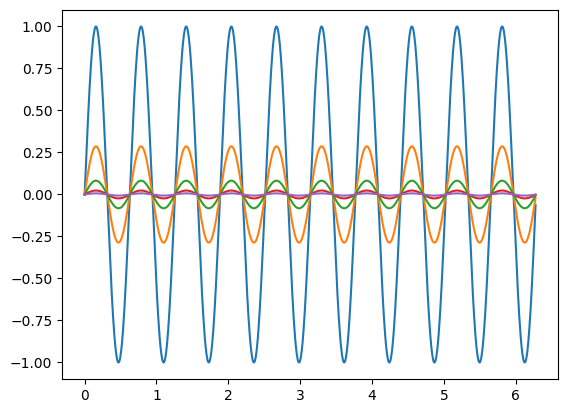

In [4]:
t_vals = np.linspace(0.0, 0.05, 5)

for t_obs in t_vals:
    factTemp = np.exp(-dDifusion * (kVals**2) * t_obs)
    T0_tilde_temp = T0_tilde * factTemp
    T_xt = np.real(np.fft.ifft(T0_tilde_temp))
    plt.plot(x, T_xt)

La gráfica tiene comportamiento esperado, la forma espacial sigue siendo sinusoidal y la amplitud disminuye con el tiempo, dado el factor de amplitud dependiente del tiempo y que decrece exponencialmente.

## Problema 3: difusión con condiciones periódicas

### (a) Aproximación de tiempos cortos con función de Green

Para la ecuación
$$
\frac{\partial \rho}{\partial t}=D\frac{\partial^2 \rho}{\partial x^2}
$$
sabemos por la clase pasada que la función de Green o kernel del sistema:
$$
G(x,t)=\frac{1}{\sqrt{4\pi Dt}}\exp\!\left(-\frac{x^2}{4Dt}\right)
$$
Usando la condición inicial,
$$
\rho(x,0)=\sum_{n=-\infty}^{\infty}\delta(x-nL),
$$
la solución exacta se obtiene sumando:
$$
\rho(x,t)=\sum_{n=-\infty}^{\infty}
\frac{1}{\sqrt{4\pi Dt}}
\exp\!\left[-\frac{(x-nL)^2}{4Dt}\right].
$$

Tenemos que
$$
-L/2 -L < x-L < L/2 -L \quad\Rightarrow\quad x-L < -L/2 \quad\Rightarrow\quad |x-L| > L/2
$$
Es decir,
$$
\exp\!\left(-\frac{(x-L)^2}{4Dt}\right) < \exp\!\left(-\frac{L^2}{4Dt}\right)
$$
Notamos que además este término es extremadamente pequeño dado que $Dt << L^2$, por lo que la única contribución relevante:

$$
\boxed{
\rho(x,t)\approx
\frac{1}{\sqrt{4\pi Dt}}
\exp\!\left(-\frac{x^2}{4Dt}\right),
\qquad
-\frac{L}{2}<x<\frac{L}{2},
\quad
t\ll \frac{L^2}{D}.
}
$$

### (b) Aproximación de tiempos largos por serie de Fourier

Partimos de que

$$
f(x) = \sum_{n=-\infty}^{\infty} c_n e^{i \frac{2\pi n}{T}x} \quad;\quad T=L
$$

Expandimos $\rho$

$$
\rho(x,t)=\sum_{n=-\infty}^{\infty} c_n(t) e^{i\frac{2\pi n}{L}x}
$$

Usamos la cond. inicial

$$
\rho(x,0)=\sum_{n=-\infty}^{\infty} c_n(0)e^{i\frac{2\pi n}{L}x} = \sum_{n=-\infty}^{\infty} \delta(x-nL)
$$

Calculamos $c_0$ con la fórmula del coeficiente

$$
c_n(0) = \frac{1}{L} \int_{-L/2}^{L/2} \rho(x,0)e^{-i\frac{2\pi n}{L}x}dx
$$
$$
c_n(0) = \frac{1}{L} \int_{-L/2}^{L/2} \left[ \sum_{n=-\infty}^{\infty} \delta(x-nL) \right] e^{-i\frac{2\pi}{L}x}dx
$$

Notamos que todos los términos con $\pm nL=\pm 1L,\pm 2L,\pm 3L,...,\pm mL$ están fuera de la integración, sólo queda:

$$
c_n(0) = \frac{1}{L} \int_{-L/2}^{L/2} \delta(x) e^{-i\frac{2\pi}{L}x}dx
$$

Sabiendo que $\int\delta(x)f(x)dx=f(0)$, vemos que

$$
c_n(0) = \frac{1}{L} e^{0} = 1/L
$$

Ahora bien, sabiendo gracias a la clase pasada (solo que en forma discreta) que:

$$
c_n(t) = c_n(0) e^{-D(2\pi n/L)^2t} = \frac{1}{L} e^{-D(2\pi n/L)^2t}
$$

Entonces completanto $\rho$

$$
\rho(x,t)=\sum_{n=-\infty}^{\infty} \frac{1}{L} e^{-D(2\pi n/L)^2t} e^{i\frac{2\pi n}{L}x}
$$

Notamos que se va reduciendo exponencialmente con cada $n$, calculamos para $n=-1,0,1$:

$$
\rho(x,t) \approx \frac{1}{L} +
\frac{1}{L} e^{-D(2\pi/L)^2t} e^{i\frac{2\pi}{L}x} +
\frac{1}{L} e^{-D(2\pi/L)^2t} e^{-i\frac{2\pi}{L}x}
$$

$$
\rho(x,t) \approx \frac{1}{L} + \frac{1}{L} e^{-D(2\pi/L)^2t} \left(e^{i\frac{2\pi}{L}x} + e^{-i\frac{2\pi}{L}x}\right) \quad;\quad e^{i\theta} + e^{-i\theta} = 2cos\theta
$$

$$
\rho(x,t) \approx \frac{1}{L} + \frac{1}{L} e^{-D(2\pi/L)^2t} 2\cos\left(\frac{2\pi x}{L}\right)
$$

### (c) Validación computacional de la aproximación de tiempos cortos

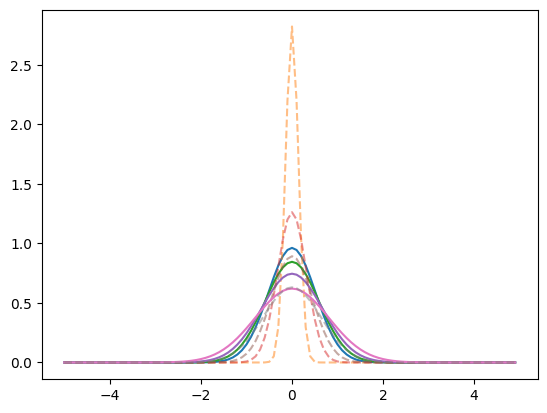

In [5]:
import numpy as np
import matplotlib.pyplot as plt

L = 10
N = 100
D = 1

x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = L/N

# Gaussianas
sigma = 0.05*L
rho0 = np.exp(-x**2/(2*sigma**2))

# FFT
rho0_k = np.fft.fft(rho0)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

# tiempos
times = [0.01, 0.05, 0.1, 0.2]

plt.figure()

for t in times:
    rho_k_t = rho0_k * np.exp(-D*k**2*t)
    rho_t = np.fft.ifft(rho_k_t).real
    plt.plot(x, rho_t, label=f"FFT t={t}")

    # aproximación inciso (a)
    rho_approx = (1/np.sqrt(4*np.pi*D*t))*np.exp(-x**2/(4*D*t))
    plt.plot(x, rho_approx, '--', alpha=0.5)

La figura compara la evolución temporal obtenida numéricamente mediante FFT con la solución analítica de la ecuación de difusión en espacio infinito (función de Green). Se observa que, para tiempos cortos, ambas soluciones coinciden muy bien, lo que indica que el sistema aún no percibe la periodicidad del dominio y se comporta efectivamente como un sistema infinito. No obstante, a medida que el tiempo aumenta, la solución numérica comienza a desviarse de la aproximación analítica.